In [3]:
tickers = ["AMD", "NVDA", "INTC", "QCOM", "AVGO", "TXN", "MU", "ON", "MRVL", "ADI"]

In [4]:
import yfinance as yf
import pandas as pd

rows = []
for t in tickers:
    info = yf.Ticker(t).info
    rows.append({
        "ticker": t,
        "trailingPE": info.get("trailingPE"),
        "forwardPE": info.get("forwardPE"),
        "evToEbitda": info.get("enterpriseToEbitda"),
        "priceToBook": info.get("priceToBook"),
        "profitMargin": info.get("profitMargins"),
        "revenueGrowth": info.get("revenueGrowth"),
    })

df = pd.DataFrame(rows)
df

,ticker,trailingPE,forwardPE,evToEbitda,priceToBook,profitMargin,revenueGrowth
0,AMD,161.700000,40.501095,106.734,15.309897,0.15577,0.501
1,NVDA,28.453857,14.351548,26.774,23.734050,0.63663,1.059
2,INTC,NaN,59.648514,40.319,7.085662,-0.19794,0.254
3,QCOM,23.108696,19.793200,18.258,7.718501,0.21013,-0.040
4,AVGO,44.943950,18.203583,32.681,16.895412,0.42944,0.855
5,TXN,42.259880,26.122492,26.704,14.098768,0.31111,0.228
6,MU,24.491516,6.785805,17.600,12.131145,0.55906,3.457
7,ON,50.457516,17.045328,14.040,4.163296,0.10168,0.092
8,MRVL,86.447200,38.763550,80.141,12.393423,0.27935,0.365
9,ADI,46.745842,24.076164,27.769,5.684658,0.29787,0.396


In [5]:
df = df.dropna(subset=["trailingPE", "evToEbitda"])
df = df[df["trailingPE"] > 0]  

,ticker,trailingPE,forwardPE,evToEbitda,priceToBook,profitMargin,revenueGrowth
0,AMD,161.700000,40.501095,106.734,15.309897,0.15577,0.501
1,NVDA,28.453857,14.351548,26.774,23.734050,0.63663,1.059
3,QCOM,23.108696,19.793200,18.258,7.718501,0.21013,-0.040
4,AVGO,44.943950,18.203583,32.681,16.895412,0.42944,0.855
5,TXN,42.259880,26.122492,26.704,14.098768,0.31111,0.228
6,MU,24.491516,6.785805,17.600,12.131145,0.55906,3.457
7,ON,50.457516,17.045328,14.040,4.163296,0.10168,0.092
8,MRVL,86.447200,38.763550,80.141,12.393423,0.27935,0.365
9,ADI,46.745842,24.076164,27.769,5.684658,0.29787,0.396


In [6]:
for col in ["trailingPE", "evToEbitda", "priceToBook"]:
    mean = df[col].mean()
    std = df[col].std()
    df[col + "_z"] = (df[col] - mean) / std

df.sort_values("trailingPE_z")

,ticker,trailingPE,forwardPE,evToEbitda,priceToBook,profitMargin,revenueGrowth,trailingPE_z,evToEbitda_z,priceToBook_z
3,QCOM,23.108696,19.793200,18.258,7.718501,0.21013,-0.040,-0.762374,-0.644543,-0.780726
6,MU,24.491516,6.785805,17.600,12.131145,0.55906,3.457,-0.730814,-0.665022,-0.053964
1,NVDA,28.453857,14.351548,26.774,23.734050,0.63663,1.059,-0.640380,-0.379490,1.857033
5,TXN,42.259880,26.122492,26.704,14.098768,0.31111,0.228,-0.325281,-0.381668,0.270103
4,AVGO,44.943950,18.203583,32.681,16.895412,0.42944,0.855,-0.264022,-0.195639,0.730710
9,ADI,46.745842,24.076164,27.769,5.684658,0.29787,0.396,-0.222897,-0.348521,-1.115699
7,ON,50.457516,17.045328,14.040,4.163296,0.10168,0.092,-0.138184,-0.775824,-1.366267
8,MRVL,86.447200,38.763550,80.141,12.393423,0.27935,0.365,0.683219,1.281512,-0.010767
0,AMD,161.700000,40.501095,106.734,15.309897,0.15577,0.501,2.400735,2.109196,0.469576


In [7]:
df["composite_z"] = df[["trailingPE_z", "evToEbitda_z", "priceToBook_z"]].mean(axis=1)
df_sorted = df.sort_values("composite_z")
df_sorted[["ticker", "trailingPE", "evToEbitda", "priceToBook", "composite_z"]]

,ticker,trailingPE,evToEbitda,priceToBook,composite_z
7,ON,50.457516,14.040,4.163296,-0.760092
3,QCOM,23.108696,18.258,7.718501,-0.729214
9,ADI,46.745842,27.769,5.684658,-0.562373
6,MU,24.491516,17.600,12.131145,-0.483267
5,TXN,42.259880,26.704,14.098768,-0.145615
4,AVGO,44.943950,32.681,16.895412,0.090350
1,NVDA,28.453857,26.774,23.734050,0.279054
8,MRVL,86.447200,80.141,12.393423,0.651321
0,AMD,161.700000,106.734,15.309897,1.659836


In [8]:
df_sorted[["ticker", "composite_z", "profitMargin", "revenueGrowth"]]

,ticker,composite_z,profitMargin,revenueGrowth
7,ON,-0.760092,0.10168,0.092
3,QCOM,-0.729214,0.21013,-0.040
9,ADI,-0.562373,0.29787,0.396
6,MU,-0.483267,0.55906,3.457
5,TXN,-0.145615,0.31111,0.228
4,AVGO,0.090350,0.42944,0.855
1,NVDA,0.279054,0.63663,1.059
8,MRVL,0.651321,0.27935,0.365
0,AMD,1.659836,0.15577,0.501


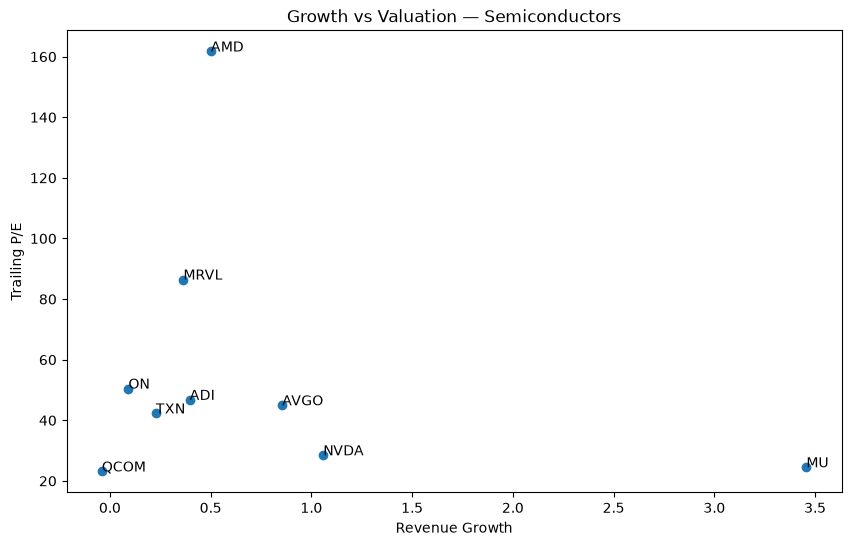

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df["revenueGrowth"], df["trailingPE"])
for i, row in df.iterrows():
    plt.annotate(row["ticker"], (row["revenueGrowth"], row["trailingPE"]))
plt.xlabel("Revenue Growth")
plt.ylabel("Trailing P/E")
plt.title("Growth vs Valuation — Semiconductors")
plt.show()